In [ ]:
import os
import pathlib
from datetime import datetime
import librosa
import librosa.display as ld
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Audio
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.layers import (Activation, Conv1D, Dense, Dropout, Flatten, MaxPooling1D)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import seaborn as sns
from keras.models import load_model
import soundfile as sf
sns.set()

In [ ]:
!pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 25.7 MB/s eta 0:00:00


In [ ]:
pip install ffmpeg-python

In [ ]:
pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.6/798.6 kB 6.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.1/168.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.0 MB/s eta 0:00:00
  Created wheel for openai-whisper: filename=openai_whisper-20231117-py3-none-any.whl size=801359 sha256=f5d820eec3fd4f93559ad1e8af192484a08ba9df2bbd404bb21d66316a333a1d
  Stored in directory: /root/.cache/pip/wheels/d0/85/e1/9361b4cbea7dd4b7f6702fa4c3afc94877952eeb2b62f45f56
Successfully built openai-whisper


In [ ]:
pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.6/375.6 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.5 MB/s eta 0:00:00


In [ ]:
import whisper
import pandas as pd
import resampy

In [ ]:
import re
import pandas as pd

In [ ]:
import zipfile

In [ ]:
import glob

#Download necessário

In [ ]:
!wget https://github.com/Kaue95/INDATA_FIAP_TOTVS/raw/main/Amostra%20de%20Dados.zip
with zipfile.ZipFile('Amostra de Dados.zip', 'r') as zip_ref:
    zip_ref.extractall()
    !rm 'Amostra de Dados.zip'

--2024-09-24 02:35:07--  https://github.com/Kaue95/INDATA_FIAP_TOTVS/raw/main/Amostra%20de%20Dados.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Kaue95/INDATA_FIAP_TOTVS/main/Amostra%20de%20Dados.zip [following]
--2024-09-24 02:35:08--  https://raw.githubusercontent.com/Kaue95/INDATA_FIAP_TOTVS/main/Amostra%20de%20Dados.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 70786434 (68M) [application/zip]
Saving to: ‘Amostra de Dados.zip’

Amostra de Dados.zi 100%[===================>]  67.51M   300MB/s    in 0.2s    

2024-09-24 02:35:11 (300 MB/s) - ‘Amostra de Dados.zip’ saved [70786434/7

In [ ]:
Audios_Amostra = '/content/Amostra de Dados'
arquivos_audio = glob.glob(os.path.join(Audios_Amostra, '*.wav')) + glob.glob(os.path.join(Audios_Amostra, '*.mp3'))

#Transcrição - Whisper - Medium

In [ ]:
dados = {"Pergunta": [], "Resposta": []}

In [ ]:
df = pd.DataFrame()

In [ ]:
import re
import pandas as pd

def processar_transcricao(transcricao, nome_arquivo):
    # Regex para capturar as perguntas e respostas
    padrao_probabilidade_recomendar = re.search(r'qual a probabilidade.*?(\d+)', transcricao, re.IGNORECASE)
    padrao_agilidade_tickets = re.search(r'agilidade nos processos.*?(\d+)', transcricao, re.IGNORECASE)
    padrao_atendimento_agentes = re.search(r'atendimento.*?dos.*?agentes.*?(\d+)', transcricao, re.IGNORECASE)
    padrao_atendimento_comercial = re.search(r'comercial.*?(\d+)', transcricao, re.IGNORECASE)
    padrao_atendimento_financeiro = re.search(r'financeiro.*?(\d+)', transcricao, re.IGNORECASE)
    padrao_custos_produtos = re.search(r'custos.*?(\d+)', transcricao, re.IGNORECASE)
    padrao_implantacao = re.search(r'implantação.*?(\d+)', transcricao, re.IGNORECASE)

    # Regex para captura de "atende à necessidade"
    padrao_atende_necessidade = re.search(
        r'(entrega\s+(totalmente|total|parcialmente|parcial|não entrega|não.*?satisfatória|insatisfatória|não.*?atende|não.*?resolve)|'
        r'(satisfação\s+(total|parcial|nenhuma)|atende\s+(totalmente|parcialmente|não))|'
        r'(\d+\s*por cento\s*de\s*satisfação|satisfeito|satisfeita|insatisfeito|insatisfeita))',
        transcricao,
        re.IGNORECASE
    )

    # Inicializa a classificação
    atende_necessidade = None

    # Verifica se encontrou a resposta de "atende à necessidade"
    if padrao_atende_necessidade:
        # Mapeia as classificações corretamente
        if 'totalmente' in padrao_atende_necessidade.group(0).lower() or 'total' in padrao_atende_necessidade.group(0).lower():
            atende_necessidade = "total"
        elif 'parcialmente' in padrao_atende_necessidade.group(0).lower() or 'parcial' in padrao_atende_necessidade.group(0).lower():
            atende_necessidade = "parcial"
        else:
            atende_necessidade = "não entrega"  # Qualquer outro caso não captura a entrega total ou parcial
    else:
        # Fallback: Busca por palavras relacionadas indiretamente
        if re.search(r'reclamação|deixa a desejar|não satisfaz|não corresponde|não atende', transcricao, re.IGNORECASE):
            atende_necessidade = "parcial"
        elif re.search(r'não.*?resolve|não.*?atende|não.*?satisfeito|não entrega|insatisfatório', transcricao, re.IGNORECASE):
            atende_necessidade = "não entrega"

    # Criando um dicionário com os valores encontrados
    dados = {
        'NOME_ARQUIVO': nome_arquivo,
        'PROBABILIDADE_RECOMENDACAO': padrao_probabilidade_recomendar.group(1) if padrao_probabilidade_recomendar else None,
        'AGILIDADE_PROCESSO': padrao_agilidade_tickets.group(1) if padrao_agilidade_tickets else None,
        'ATENDIMENTO_AGENTES': padrao_atendimento_agentes.group(1) if padrao_atendimento_agentes else None,
        'ATENDIMENTO_COMERCIAL': padrao_atendimento_comercial.group(1) if padrao_atendimento_comercial else None,
        'ATENDIMENTO_FINANCEIRO': padrao_atendimento_financeiro.group(1) if padrao_atendimento_financeiro else None,
        'CUSTOS_PRODUTOS': padrao_custos_produtos.group(1) if padrao_custos_produtos else None,
        'IMPLATACAO': padrao_implantacao.group(1) if padrao_implantacao else None,
        'ATENDE_NECESSIDADE': atende_necessidade if atende_necessidade else None
    }

    return dados


In [ ]:
def processar_audio(arquivo_audio):
    # Carregar o modelo Whisper
    modelo = whisper.load_model("medium")

    # Transcrever o áudio
    transcricao = modelo.transcribe(arquivo_audio)

    # Pegar o nome do arquivo (extraindo o nome do caminho)
    nome_arquivo = arquivo_audio.split('/')[-1]

    # Limpar o texto da transcrição
    transcricao = transcricao['text']
    transcricao = transcricao.lower()

    salvar_transcricao(transcricao,nome_arquivo)

    # Processar a transcrição e extrair os dados
    dados = processar_transcricao(transcricao, nome_arquivo)

    return dados



In [ ]:
# Inicializa o DataFrame para armazenar as transcrições
df_transcricoes = pd.DataFrame(columns=['NOME_ARQUIVO', 'TRANSCRICAO'])

# Função para adicionar transcrição e nome do arquivo ao dataset
def salvar_transcricao(transcricao, nome_arquivo):
    # Cria um dicionário com o nome do arquivo e a transcrição
    dados_transcricao = {
        'NOME_ARQUIVO': nome_arquivo,
        'TRANSCRICAO': transcricao
    }

    # Converte para DataFrame temporário e adiciona ao principal
    temp_df = pd.DataFrame([dados_transcricao])
    global df_transcricoes
    df_transcricoes = pd.concat([df_transcricoes, temp_df], ignore_index=True)

    # Salva em um arquivo CSV conforme o progresso
    df_transcricoes.to_csv('transcricoes.csv', index=False)

In [ ]:
for arquivo in arquivos_audio:
    dados_audio = processar_audio(arquivo)
    temp_df = pd.DataFrame([dados_audio])
    df = pd.concat([df, temp_df], ignore_index=True)
    temp_df.to_csv('indata.csv', mode='a', header=not os.path.exists('indata.csv'), index=False)

In [ ]:
def filtrar(caminho_df):
  # Carregar o dataset existente
  df = pd.read_csv(caminho_df)

  # Exibir as primeiras linhas do DataFrame para verificar a estrutura
  print("Dados originais:")
  print(df.head())

  # Filtrar e substituir valores fora do intervalo [0, 10] nas colunas numéricas
  colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns

  for coluna in colunas_numericas:
      df[coluna] = df[coluna].apply(lambda x: x if 0 <= x <= 10 else None)

  # Exibir as primeiras linhas do DataFrame filtrado
  print("Dados filtrados:")
  print(df.head())

  # Salvar o DataFrame filtrado em um novo arquivo CSV
  df.to_csv('indata.csv', index=False)

In [ ]:
filtrar('/content/indata.csv')

Dados originais:
  NOME_ARQUIVO  PROBABILIDADE_RECOMENDACAO  AGILIDADE_PROCESSO  \
0  2968540.wav                        10.0                 0.0   
1  2966683.wav                         NaN                 NaN   
2  2966760.wav                        10.0                 8.0   
3  2966719.wav                        10.0                 0.0   
4  2968468.wav                         7.0                 7.0   

   ATENDIMENTO_AGENTES  ATENDIMENTO_COMERCIAL  ATENDIMENTO_FINANCEIRO  \
0                  NaN                    NaN                     0.0   
1                  NaN                    NaN                    20.0   
2                 10.0                   10.0                    10.0   
3                  5.0                    8.0                    10.0   
4                  NaN                    NaN                     NaN   

   CUSTOS_PRODUTOS  IMPLATACAO ATENDE_NECESSIDADE  
0              NaN         0.0              total  
1              NaN         NaN             

In [ ]:
pd.read_csv('indata.csv')

,NOME_ARQUIVO,PROBABILIDADE_RECOMENDACAO,AGILIDADE_PROCESSO,ATENDIMENTO_AGENTES,ATENDIMENTO_COMERCIAL,ATENDIMENTO_FINANCEIRO,CUSTOS_PRODUTOS,IMPLATACAO,ATENDE_NECESSIDADE
0,2968540.wav,10.0,0.0,NaN,NaN,0.0,NaN,0.0,total
1,2966683.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2966760.wav,10.0,8.0,10.0,10.0,10.0,8.0,9.0,parcial
3,2966719.wav,10.0,0.0,5.0,8.0,10.0,3.0,10.0,total
4,2968468.wav,7.0,7.0,NaN,NaN,NaN,NaN,NaN,total
5,2968125.wav,9.0,0.0,10.0,10.0,10.0,0.0,0.0,total
6,2967703.wav,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN
7,2966138.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2966819.wav,8.0,8.0,8.0,8.0,8.0,NaN,NaN,parcial
9,2966642.wav,10.0,10.0,10.0,5.0,NaN,NaN,NaN,total


##Processamento de Modelo de Sentimento

## Baixando e carregando os datasets:

### RAVDESS - SPEECH/SONG

* arquivos de fala (Audio_Speech_Actors) contém 1440 arquivos;
* arquivos de música (Audio_Song_Actors) contém 1012 arquivos.

In [ ]:
!wget https://zenodo.org/record/1188976/files/Audio_Song_Actors_01-24.zip -O Audio_Song_Actors_01-24.zip
!unzip Audio_Song_Actors_01-24.zip -d '/content/Audio_Song_Actors'
!rm Audio_Song_Actors_01-24.zip

--2024-09-24 02:37:03--  https://zenodo.org/record/1188976/files/Audio_Song_Actors_01-24.zip
Resolving zenodo.org (zenodo.org)... 188.184.103.159, 188.185.79.172, 188.184.98.238, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.159|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1188976/files/Audio_Song_Actors_01-24.zip [following]
--2024-09-24 02:37:04--  https://zenodo.org/records/1188976/files/Audio_Song_Actors_01-24.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 225505317 (215M) [application/octet-stream]
Saving to: ‘Audio_Song_Actors_01-24.zip’

Audio_Song_Actors_0 100%[===================>] 215.06M  12.1MB/s    in 19s     

2024-09-24 02:37:24 (11.1 MB/s) - ‘Audio_Song_Actors_01-24.zip’ saved [225505317/225505317]

Archive:  Audio_Song_Actors_01-24.zip
   creating: /content/Audio_Song_Actors/Actor_01/
  inflating: /content/Audio_Song_Actors/Actor_01/03-02-01-01-01-0

In [ ]:
!wget https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip -O Audio_Speech_Actors_01-24.zip
!unzip Audio_Speech_Actors_01-24.zip -d '/content/Audio_Speech_Actors'
!rm Audio_Speech_Actors_01-24.zip

--2024-09-24 02:37:30--  https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
Resolving zenodo.org (zenodo.org)... 188.185.79.172, 188.184.103.159, 188.184.98.238, ...
Connecting to zenodo.org (zenodo.org)|188.185.79.172|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1188976/files/Audio_Speech_Actors_01-24.zip [following]
--2024-09-24 02:37:31--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘Audio_Speech_Actors_01-24.zip’

Audio_Speech_Actors 100%[===================>] 198.81M  20.1MB/s    in 12s     

2024-09-24 02:37:44 (16.3 MB/s) - ‘Audio_Speech_Actors_01-24.zip’ saved [208468073/208468073]

Archive:  Audio_Speech_Actors_01-24.zip
   creating: /content/Audio_Speech_Actors/Actor_01/
  inflating: /content/Audio_Speech_Actors/Actor_01/0

### TESS

Para esta base de dados precisamos fazer o download manual através do link: https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi%3A10.5683%2FSP2%2FE8H2MF

Clicar no botão Acess Dataset / Donwload ZIP (268.3 MB)

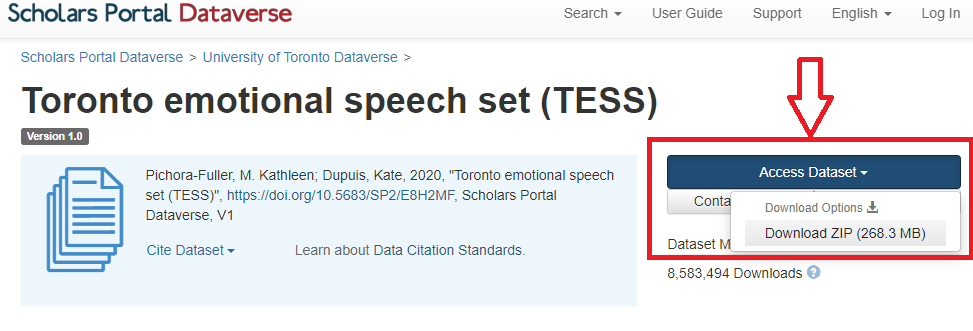



In [ ]:
import gdown
url = 'https://drive.google.com/file/d/1_U85NkK1DDEeKLOE36mSkds_kgdGrokI/view?usp=sharing'
output = '/content/Tess/'
gdown.download(url = url, output = output, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=1_U85NkK1DDEeKLOE36mSkds_kgdGrokI
From (redirected): https://drive.google.com/uc?id=1_U85NkK1DDEeKLOE36mSkds_kgdGrokI&confirm=t&uuid=30dc20ba-53a8-4fcf-b478-23970c6030e1
To: /content/Tess/Tess.zip
100%|██████████| 224M/224M [00:06<00:00, 35.8MB/s]


'/content/Tess/Tess.zip'

In [ ]:
%cd /content/Tess/

/content/Tess


In [ ]:
!unzip Tess.zip -x "*.TXT*" -d '/content/Tess/'
!rm Tess.zip
%cd ..

Archive:  Tess.zip
  inflating: /content/Tess/OAF_back_angry.wav  
  inflating: /content/Tess/OAF_back_disgust.wav  
  inflating: /content/Tess/OAF_back_fear.wav  
  inflating: /content/Tess/OAF_back_happy.wav  
  inflating: /content/Tess/OAF_back_neutral.wav  
  inflating: /content/Tess/OAF_back_ps.wav  
  inflating: /content/Tess/OAF_back_sad.wav  
  inflating: /content/Tess/OAF_bar_angry.wav  
  inflating: /content/Tess/OAF_bar_disgust.wav  
  inflating: /content/Tess/OAF_bar_fear.wav  
  inflating: /content/Tess/OAF_bar_happy.wav  
  inflating: /content/Tess/OAF_bar_neutral.wav  
  inflating: /content/Tess/OAF_bar_ps.wav  
  inflating: /content/Tess/OAF_bar_sad.wav  
  inflating: /content/Tess/OAF_base_angry.wav  
  inflating: /content/Tess/OAF_base_disgust.wav  
  inflating: /content/Tess/OAF_base_fear.wav  
  inflating: /content/Tess/OAF_base_happy.wav  
  inflating: /content/Tess/OAF_base_neutral.wav  
  inflating: /content/Tess/OAF_base_ps.wav  
  inflating: /content/Tess/OAF_b

## Criando os datasets

### RAVDESS

In [ ]:
modalitys = []
voc_channels = []
emotions = []
intensitys = []
phrases =[]
actors = []

full_path = []

def create_dataset(DATASET):
  for root, dirs, files in tqdm(os.walk(DATASET)):
      for file in files:
          try:
              modal = int(file[1:2])
              vchan = int(file[4:5])
              label = int(file[7:8])
              ints = int(file[10:11])
              phr = int(file[13:14])
              act = int(file[19:20])

              modalitys.append(modal)
              voc_channels.append(vchan)
              emotions.append(label)
              intensitys.append(ints)
              phrases.append(phr)
              actors.append(act)

              full_path.append((root, file))

          except ValueError:
              continue

In [ ]:
create_dataset('/content/Audio_Speech_Actors')
create_dataset('/content/Audio_Song_Actors')

25it [00:00, 2836.60it/s]
25it [00:00, 4656.82it/s]


In [ ]:
len(emotions)

2452

**Criação da lista de emoções que será utilizada por todo o código**

In [ ]:
# 1 = neutra, 2 = calma, 3 = feliz, 4 = triste, 5 = nervosa, 6 = medo, 7 = nojo, 8 = surpreso
emotions_list = ['neutra', 'calma', 'feliz', 'triste', 'nervosa', 'medo', 'nojo', 'surpreso']
emotion_dict = {em[0]+1:em[1] for em in enumerate(emotions_list)}
emotion_dict

{1: 'neutra',
 2: 'calma',
 3: 'feliz',
 4: 'triste',
 5: 'nervosa',
 6: 'medo',
 7: 'nojo',
 8: 'surpreso'}

In [ ]:
RAVDESS_df = pd.DataFrame([emotions, voc_channels, modalitys, intensitys, actors, phrases, full_path]).T

In [ ]:
RAVDESS_df.columns = ['emotion', 'voc_channel', 'modality', 'intensity', 'actors', 'phrase', 'path']
RAVDESS_df['emotion'] = RAVDESS_df['emotion'].map(emotion_dict)
RAVDESS_df['voc_channel'] = RAVDESS_df['voc_channel'].map({1: 'fala', 2:'musica'})
RAVDESS_df['modality'] = RAVDESS_df['modality'].map({1: 'AV completo', 2:'apenas video', 3:'apenas audio'})
RAVDESS_df['intensity'] = RAVDESS_df['intensity'].map({1: 'normal', 2:'forte'})
RAVDESS_df['actors'] = RAVDESS_df['actors'].apply(lambda x: 'feminino' if x%2 == 0 else 'masculino')
RAVDESS_df['phrase'] = RAVDESS_df['phrase'].map({1: 'Kids are talking by the door', 2:'Dogs are sitting by the door'}) # Não traduzimos a frase, pois nesta base de dados, os áudios estão sendo falados em inglês
RAVDESS_df['path'] = RAVDESS_df['path'].apply(lambda x: x[0] + '/' + x[1])
RAVDESS_df

,emotion,voc_channel,modality,intensity,actors,phrase,path
0,nervosa,fala,apenas audio,normal,masculino,Kids are talking by the door,/content/Audio_Speech_Actors/Actor_05/03-01-05...
1,nojo,fala,apenas audio,normal,masculino,Kids are talking by the door,/content/Audio_Speech_Actors/Actor_05/03-01-07...
2,calma,fala,apenas audio,normal,masculino,Kids are talking by the door,/content/Audio_Speech_Actors/Actor_05/03-01-02...
3,triste,fala,apenas audio,normal,masculino,Dogs are sitting by the door,/content/Audio_Speech_Actors/Actor_05/03-01-04...
4,calma,fala,apenas audio,forte,masculino,Dogs are sitting by the door,/content/Audio_Speech_Actors/Actor_05/03-01-02...
...,...,...,...,...,...,...,...
2447,calma,musica,apenas audio,normal,masculino,Kids are talking by the door,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2448,calma,musica,apenas audio,forte,masculino,Kids are talking by the door,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2449,calma,musica,apenas audio,forte,masculino,Kids are talking by the door,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2450,medo,musica,apenas audio,forte,masculino,Kids are talking by the door,/content/Audio_Song_Actors/Actor_23/03-02-06-0...


In [ ]:
RAVDESS_df.emotion.value_counts()

,count
emotion,
nervosa,376
calma,376
triste,376
medo,376
feliz,376
nojo,192
surpreso,192
neutra,188


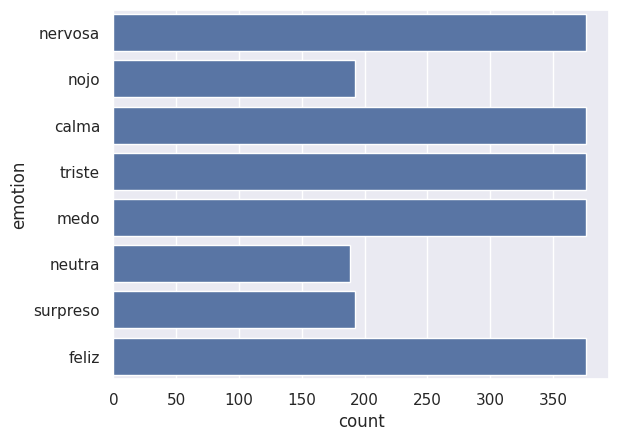

In [ ]:
sns.countplot(RAVDESS_df.emotion);

### TESS

In [ ]:
dir_list = os.listdir('/content/Tess')
dir_list.sort()
print(dir_list)

['OAF_back_angry.wav', 'OAF_back_disgust.wav', 'OAF_back_fear.wav', 'OAF_back_happy.wav', 'OAF_back_neutral.wav', 'OAF_back_ps.wav', 'OAF_back_sad.wav', 'OAF_bar_angry.wav', 'OAF_bar_disgust.wav', 'OAF_bar_fear.wav', 'OAF_bar_happy.wav', 'OAF_bar_neutral.wav', 'OAF_bar_ps.wav', 'OAF_bar_sad.wav', 'OAF_base_angry.wav', 'OAF_base_disgust.wav', 'OAF_base_fear.wav', 'OAF_base_happy.wav', 'OAF_base_neutral.wav', 'OAF_base_ps.wav', 'OAF_base_sad.wav', 'OAF_bath_angry.wav', 'OAF_bath_disgust.wav', 'OAF_bath_fear.wav', 'OAF_bath_happy.wav', 'OAF_bath_neutral.wav', 'OAF_bath_ps.wav', 'OAF_bath_sad.wav', 'OAF_bean_angry.wav', 'OAF_bean_disgust.wav', 'OAF_bean_fear.wav', 'OAF_bean_happy.wav', 'OAF_bean_neutral.wav', 'OAF_bean_ps.wav', 'OAF_bean_sad.wav', 'OAF_beg_angry.wav', 'OAF_beg_disgust.wav', 'OAF_beg_fear.wav', 'OAF_beg_happy.wav', 'OAF_beg_neutral.wav', 'OAF_beg_ps.wav', 'OAF_beg_sad.wav', 'OAF_bite_angry.wav', 'OAF_bite_disgust.wav', 'OAF_bite_fear.wav', 'OAF_bite_happy.wav', 'OAF_bite_ne

In [ ]:
path = []
emotion = []

for i in dir_list:
  if 'angry' in i:
    emotion.append('nervosa')
  if 'disgust' in i:
    emotion.append('nojo')
  if 'fear' in i:
    emotion.append('medo')
  if 'happy' in i:
    emotion.append('feliz')
  if 'neutral' in i:
    emotion.append('neutra')
  if 'ps' in i:
    emotion.append('surpreso')
  if 'sad' in i:
    emotion.append('triste')
  path.append('/content/Tess/' + i)

In [ ]:
print(path)
print(emotion)

['/content/Tess/OAF_back_angry.wav', '/content/Tess/OAF_back_disgust.wav', '/content/Tess/OAF_back_fear.wav', '/content/Tess/OAF_back_happy.wav', '/content/Tess/OAF_back_neutral.wav', '/content/Tess/OAF_back_ps.wav', '/content/Tess/OAF_back_sad.wav', '/content/Tess/OAF_bar_angry.wav', '/content/Tess/OAF_bar_disgust.wav', '/content/Tess/OAF_bar_fear.wav', '/content/Tess/OAF_bar_happy.wav', '/content/Tess/OAF_bar_neutral.wav', '/content/Tess/OAF_bar_ps.wav', '/content/Tess/OAF_bar_sad.wav', '/content/Tess/OAF_base_angry.wav', '/content/Tess/OAF_base_disgust.wav', '/content/Tess/OAF_base_fear.wav', '/content/Tess/OAF_base_happy.wav', '/content/Tess/OAF_base_neutral.wav', '/content/Tess/OAF_base_ps.wav', '/content/Tess/OAF_base_sad.wav', '/content/Tess/OAF_bath_angry.wav', '/content/Tess/OAF_bath_disgust.wav', '/content/Tess/OAF_bath_fear.wav', '/content/Tess/OAF_bath_happy.wav', '/content/Tess/OAF_bath_neutral.wav', '/content/Tess/OAF_bath_ps.wav', '/content/Tess/OAF_bath_sad.wav', '/cont

In [ ]:
TESS_df = pd.DataFrame(emotion, columns = ['emotion_label'])
TESS_df['source'] = 'TESS'
TESS_df['actors'] = 'feminino'
TESS_df = pd.concat([TESS_df, pd.DataFrame(path, columns=['path'])], axis=1)
TESS_df

,emotion_label,source,actors,path
0,nervosa,TESS,feminino,/content/Tess/OAF_back_angry.wav
1,nojo,TESS,feminino,/content/Tess/OAF_back_disgust.wav
2,medo,TESS,feminino,/content/Tess/OAF_back_fear.wav
3,feliz,TESS,feminino,/content/Tess/OAF_back_happy.wav
4,neutra,TESS,feminino,/content/Tess/OAF_back_neutral.wav
...,...,...,...,...
2795,medo,TESS,feminino,/content/Tess/YAF_youth_fear.wav
2796,feliz,TESS,feminino,/content/Tess/YAF_youth_happy.wav
2797,neutra,TESS,feminino,/content/Tess/YAF_youth_neutral.wav
2798,surpreso,TESS,feminino,/content/Tess/YAF_youth_ps.wav


## Visualizando a distribuição do TESS

In [ ]:
TESS_df['emotion_label'].value_counts()

,count
emotion_label,
nervosa,400
nojo,400
medo,400
feliz,400
neutra,400
surpreso,400
triste,400


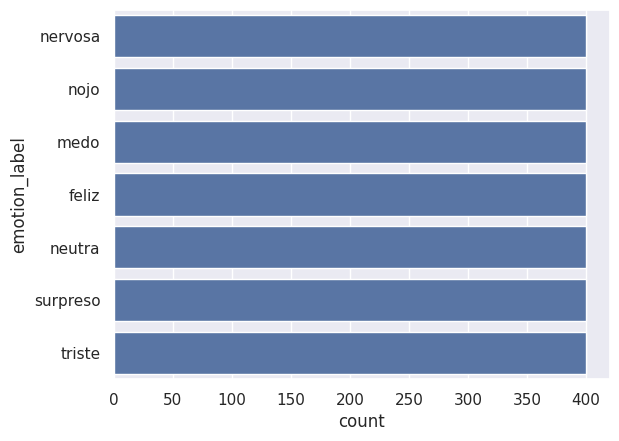

In [ ]:
sns.countplot(TESS_df['emotion_label']);

## Visalizando os dados de áudio - RAVDESS
### Waveforms

Canais: (192192,)
Número total de amostras: 192192
Arquivo: /content/Audio_Speech_Actors/Actor_21/03-01-02-02-01-01-21.wav
Taxa de amostragem:  48000
Duração): 4.004


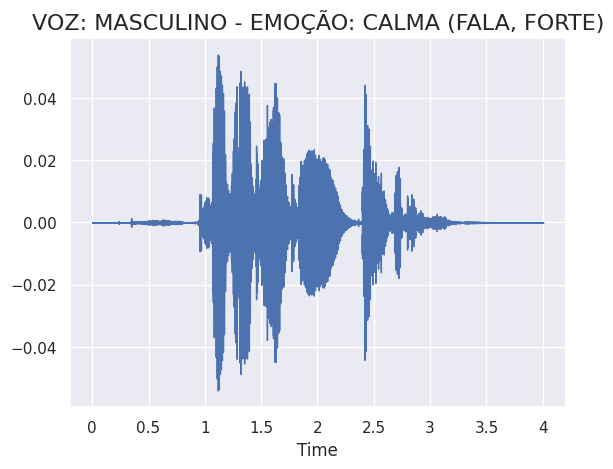

In [ ]:
n_files = RAVDESS_df.shape[0]
rnd = np.random.randint(0, n_files)
fname = RAVDESS_df.path[rnd]
data, sample_rate = librosa.load(fname, sr=None)

print('Canais:', data.shape)
print('Número total de amostras:', data.shape[0])
print('Arquivo:', fname)
print('Taxa de amostragem: ', sample_rate)
print('Duração):', len(data) / sample_rate)

# 0 = Emoção, 1 = Canal vocal, 2 = Modalidade, 3 = Intensidade emocional, 4 = Ator, 5 = Frase
info = RAVDESS_df.iloc[rnd].values
title_txt = f'voz: {info[4]} - emoção: {info[0]} ({info[1]}, {info[3]})'
plt.title(title_txt.upper(), size=16)
ld.waveshow(data, sr=sample_rate)
Audio(data = data, rate = sample_rate)

## Visalizando os dados de áudio - TESS
### Waveforms

Canais: (62221,)
Número total de amostras: 62221
Arquivo: /content/Tess/YAF_keep_disgust.wav
Taxa de amostragem:  24414
Duração): 2.548578684361432


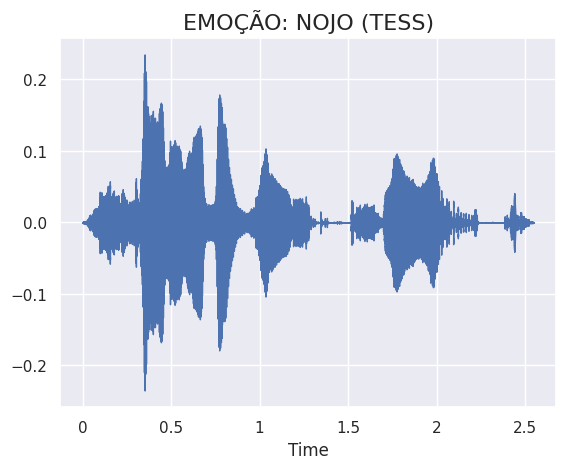

In [ ]:
n_files = TESS_df.shape[0]
rnd = np.random.randint(0, n_files)
fname = TESS_df.path[rnd]
data, sample_rate = librosa.load(fname, sr=None)

print('Canais:', data.shape)
print('Número total de amostras:', data.shape[0])
print('Arquivo:', fname)
print('Taxa de amostragem: ', sample_rate)
print('Duração):', len(data) / sample_rate)

# 0 = Emoção, 1 = Canal vocal, 2 = Modalidade, 3 = Intensidade emocional, 4 = Ator, 5 = Frase
info = TESS_df.iloc[rnd].values
title_txt = f'emoção: {info[0]} ({info[1]})'
plt.title(title_txt.upper(), size=16)
ld.waveshow(data, sr=sample_rate)
Audio(data = data, rate = sample_rate)

## Juntando as bases de dados

In [ ]:
RAVDESS_df.columns

Index(['emotion', 'voc_channel', 'modality', 'intensity', 'actors', 'phrase',
       'path'],
      dtype='object')

In [ ]:
RAV_df = RAVDESS_df.copy()
RAV_df.insert(0, 'emotion_label', RAV_df['emotion'], True)
RAV_df.insert(1, 'source', 'RAV', True)
RAV_df = RAV_df.drop(columns = ['emotion', 'voc_channel', 'modality', 'intensity', 'phrase'], axis = 1)
RAV_df

,emotion_label,source,actors,path
0,nervosa,RAV,masculino,/content/Audio_Speech_Actors/Actor_05/03-01-05...
1,nojo,RAV,masculino,/content/Audio_Speech_Actors/Actor_05/03-01-07...
2,calma,RAV,masculino,/content/Audio_Speech_Actors/Actor_05/03-01-02...
3,triste,RAV,masculino,/content/Audio_Speech_Actors/Actor_05/03-01-04...
4,calma,RAV,masculino,/content/Audio_Speech_Actors/Actor_05/03-01-02...
...,...,...,...,...
2447,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2448,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2449,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2450,medo,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-06-0...


In [ ]:
df_combined = pd.concat([TESS_df, RAV_df])
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5252 entries, 0 to 2451
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   emotion_label  5252 non-null   object
 1   source         5252 non-null   object
 2   actors         5252 non-null   object
 3   path           5252 non-null   object
dtypes: object(4)
memory usage: 205.2+ KB


In [ ]:
df_combined

,emotion_label,source,actors,path
0,nervosa,TESS,feminino,/content/Tess/OAF_back_angry.wav
1,nojo,TESS,feminino,/content/Tess/OAF_back_disgust.wav
2,medo,TESS,feminino,/content/Tess/OAF_back_fear.wav
3,feliz,TESS,feminino,/content/Tess/OAF_back_happy.wav
4,neutra,TESS,feminino,/content/Tess/OAF_back_neutral.wav
...,...,...,...,...
2447,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2448,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2449,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2450,medo,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-06-0...


In [ ]:
df_combined['emotion_label'].value_counts()

,count
emotion_label,
nervosa,776
medo,776
feliz,776
triste,776
nojo,592
surpreso,592
neutra,588
calma,376


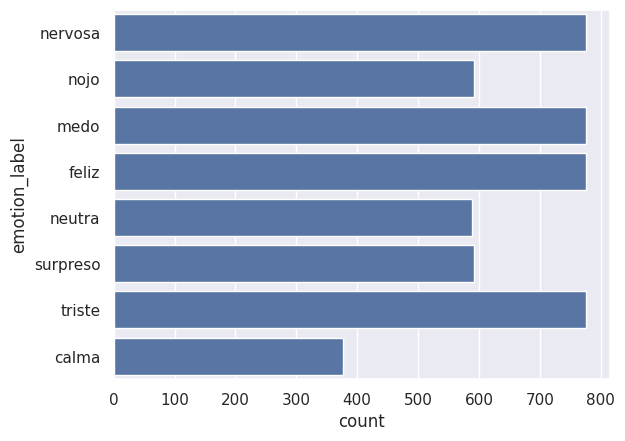

In [ ]:
sns.countplot(df_combined['emotion_label']);

In [ ]:
df_combined.to_csv('INDATA.csv', index=False)

In [ ]:
#from google.colab import files

# Baixar o arquivo
#files.download('INDATA.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_combined

,emotion_label,source,actors,path
0,nervosa,TESS,feminino,/content/Tess/OAF_back_angry.wav
1,nojo,TESS,feminino,/content/Tess/OAF_back_disgust.wav
2,medo,TESS,feminino,/content/Tess/OAF_back_fear.wav
3,feliz,TESS,feminino,/content/Tess/OAF_back_happy.wav
4,neutra,TESS,feminino,/content/Tess/OAF_back_neutral.wav
...,...,...,...,...
2447,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2448,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2449,calma,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-02-0...
2450,medo,RAV,masculino,/content/Audio_Song_Actors/Actor_23/03-02-06-0...


# Pré-processamento


### Extraindo recursos/características MFCC's de cada arquivo de áudio do dataset

Diferente dos demais projetos, onde usamos a taxa de amostragem original de cada arquivo de aúdio, neste exemplo vamos aplicar a taxa de 22050, pois como estamos utilizando 2 bases de dados diferentes, a taxa de amostragem nos arquivos de áudio de cada base de dados é diferente.


In [ ]:
from tqdm import tqdm
import resampy
import librosa
import numpy as np

**Em caso de erro no código abaixo rodando o colab é necessário reiniciar o colab,  ocorre um erro no librosa, mas ao reiniciar e rodar novamente ele some **

In [ ]:
def features_extractor(file_name):
    data, sample_rate = librosa.load(file_name, sr=22050, res_type='kaiser_fast')
    mfccs_features = librosa.feature.mfcc(y=data, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)
    return mfccs_scaled_features

extracted_features = []
for path in tqdm(df_combined.path.values):
    data = features_extractor(path)
    extracted_features.append([data])

100%|██████████| 5252/5252 [06:25<00:00, 13.61it/s]


In [ ]:
extracted_features

[[array([-3.8665387e+02,  5.7024231e+01, -2.2126987e+01, -7.3734698e+00,
         -9.0280380e+00,  1.1696811e+01, -2.9085838e+01, -3.1479361e+00,
         -1.3673544e+01,  8.1224307e-02, -2.7999465e+00,  3.4681005e+00,
         -4.7411415e-01,  5.2220092e+00,  2.2384646e+00,  3.0126748e+00,
         -4.9696541e+00, -1.8452877e+00, -4.0299387e+00, -8.1438055e+00,
         -7.2024269e+00, -1.9356500e+00, -7.0963640e+00,  1.1615892e+01,
          1.2243118e+01,  2.4487936e+01,  2.4819086e+01,  2.2555218e+01,
          1.3730143e+01,  4.6261778e+00, -1.0063000e+00,  4.4734015e+00,
          1.0148163e+01,  5.0168891e+00,  3.5018353e+00, -3.5743108e+00,
          4.1888218e+00,  7.4928312e+00,  3.0416687e+00, -3.1780646e+00],
        dtype=float32)],
 [array([-4.8750204e+02,  9.6706833e+01,  3.3183308e+00,  1.9471817e+00,
          6.7638078e+00,  9.7023878e+00, -1.0969930e+01,  5.0665917e+00,
         -1.9240416e+01,  7.4861274e+00, -1.3208656e+01,  5.9452758e+00,
         -2.4052610e+00, 

## Convertendo os recursos extraídos para visualização com Pandas

In [ ]:
extracted_features_df = pd.DataFrame(extracted_features, columns = ['feature'])
extracted_features_df

,feature
0,"[-386.65387, 57.02423, -22.126987, -7.37347, -..."
1,"[-487.50204, 96.70683, 3.3183308, 1.9471817, 6..."
2,"[-438.51077, 67.392815, -3.8827014, -2.6246781..."
3,"[-470.75894, 90.860954, 4.512022, -6.1391897, ..."
4,"[-532.169, 92.5125, 7.2209272, 7.8883386, 8.65..."
...,...
5247,"[-594.50183, 70.32526, -11.983214, 15.535121, ..."
5248,"[-604.69073, 76.66462, -9.56784, 9.370399, 12...."
5249,"[-597.44916, 67.57317, -7.4190874, 9.488868, 9..."
5250,"[-475.25238, 58.774727, -15.506826, 10.072767,..."


## Dividindo entre atributos classe(class) e atributos previsores(features)

In [ ]:
X = np.array(extracted_features_df['feature'].tolist())
y = np.array(df_combined.emotion_label.tolist())

In [ ]:
X

array([[-3.8665387e+02,  5.7024231e+01, -2.2126987e+01, ...,
         7.4928312e+00,  3.0416687e+00, -3.1780646e+00],
       [-4.8750204e+02,  9.6706833e+01,  3.3183308e+00, ...,
         3.3778374e+00,  6.4296188e+00,  6.5329404e+00],
       [-4.3851077e+02,  6.7392815e+01, -3.8827014e+00, ...,
        -4.7247428e-01, -3.9173183e-01, -3.6690801e-01],
       ...,
       [-5.9744916e+02,  6.7573174e+01, -7.4190874e+00, ...,
         9.5094385e+00,  1.3746336e+01,  1.4869736e+01],
       [-4.7525238e+02,  5.8774727e+01, -1.5506826e+01, ...,
         6.8457479e+00,  9.0747032e+00,  1.0025517e+01],
       [-5.2822034e+02,  6.2287178e+01, -2.4435585e+01, ...,
         9.0485783e+00,  1.6389029e+01,  1.6125746e+01]], dtype=float32)

In [ ]:
X.shape

(5252, 40)

In [ ]:
y.shape

(5252,)

In [ ]:
y

array(['nervosa', 'nojo', 'medo', ..., 'calma', 'medo', 'feliz'],
      dtype='<U8')

In [ ]:
labelencoder = LabelEncoder()
y = to_categorical(labelencoder.fit_transform(y))

In [ ]:
y[0]

array([0., 0., 0., 1., 0., 0., 0., 0.])

In [ ]:
y[1]

array([0., 0., 0., 0., 0., 1., 0., 0.])

In [ ]:
y[2]

array([0., 0., 1., 0., 0., 0., 0., 0.])

In [ ]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
labelencoder.classes_

array(['calma', 'feliz', 'medo', 'nervosa', 'neutra', 'nojo', 'surpreso',
       'triste'], dtype='<U8')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
X_train.shape, X_test.shape

((4201, 40), (1051, 40))

In [ ]:
y_train.shape, y_test.shape

((4201, 8), (1051, 8))

In [ ]:
X_train = X_train[:,:,np.newaxis]
X_test = X_test[:,:,np.newaxis]
X_train.shape, X_test.shape

((4201, 40, 1), (1051, 40, 1))

In [ ]:
num_labels = y.shape[1]
num_labels

8

# Criando o modelo

### Criação da estrutura da rede neural



In [ ]:
input_shape=(X_train.shape[1],1)
input_shape

(40, 1)

In [ ]:
model=Sequential()

model.add(Conv1D(64, kernel_size=(5), activation='relu',input_shape=(X_train.shape[1],1)))

model.add(Conv1D(128, kernel_size=(5),activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=(5)))

model.add(Conv1D(256, kernel_size=(5),activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=(5)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(num_labels))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 36, 64)              │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 36, 128)             │          41,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 7, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 7, 256)              │         164,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 1, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 8)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 222,536 (869.28 KB)

 Trainable params: 222,536 (869.28 KB)

 Non-trainable params: 0 (0.00 B)

 # Treinando o modelo
 * `num_epochs`, número de épocas de treinamento
 * `num_batch_size`, isto indica que vamos enviar de 32 em 32 recursos de áudio (32, 64, 96, 128,...8732)

ModelCheckpoint, para salvar o modelo enquanto faz o treinamento
 * `filepath`, caminho onde será salvo o modelo. Para isto temos uma pasta no Drive chamada *saved_models*
 * `verbose`, mostrar mensagens enquanto a rede neural é treinada
 * `save_best_only = True`, para salvar o modelo somente quando houver uma melhora no resultado

Variáveis para efetuar a contagem do tempo de treinamento:
 * `start`, pegando o horário atual de início do treinamento;
 * `duration`, ao final do treinamento, subtrair a hora atual com hora de início do treinamento.

`model_history` para armazenar o histórico de treinamento:
 * `model.fit` para fazer o ajuste do pesos ao longo do treinamento
  * `X_train`, `Y_train`, dados de treinamento
  * `batch_size = num_batch_size` que definimos acima
  * `epochs = num_epochs` que também definimos acima
  * `validation_data=(X_test, Y_test)`, dados de teste para monitorarmos como está o percentual de acerto da rede neural a cada época
  * `callbacks=[checkpointer]`, checkpointer definido anteriormente
  * `verbose = 1`, para mostrar as mensagens

In [ ]:
num_epochs = 150
num_batch_size = 64

checkpointer = ModelCheckpoint(filepath='/content/drive/MyDrive/Audio Classification/saved_models/speech_emotion_recognition.keras',
                               verbose=1, save_best_only=True)
start = datetime.now()
model_history = model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs,
                          validation_data=(X_test, y_test), callbacks=[checkpointer], verbose=1)
duration = datetime.now() - start
print("Treinamento concluído em: ", duration)

Epoch 1/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2162 - loss: 4.1582
Epoch 1: val_loss improved from inf to 1.29672, saving model to /content/drive/MyDrive/Audio Classification/saved_models/speech_emotion_recognition.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.2178 - loss: 4.1334 - val_accuracy: 0.5452 - val_loss: 1.2967
Epoch 2/150
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5489 - loss: 1.2244
Epoch 2: val_loss improved from 1.29672 to 0.91081, saving model to /content/drive/MyDrive/Audio Classification/saved_models/speech_emotion_recognition.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5494 - loss: 1.2231 - val_accuracy: 0.6603 - val_loss: 0.9108
Epoch 3/150
65/66 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6437 - loss: 0.9687
Epoch 3: val_loss improved from 0.91081 to 0.81704, saving model to /content/drive/MyDrive/Audio Classification/saved_models/speech_emotion_recognition.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step 

In [ ]:
import tensorflow as tf
#model.load_weights('/content/drive/MyDrive/Audio Classification/saved_models/speech_emotion_recognition.keras')

# Avaliando o modelo - Somente em caso de treinamento do modelo novamente

In [ ]:
model.evaluate(X_test, y_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8995 - loss: 0.5408


[0.5852888226509094, 0.8953377604484558]

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
predictions = model.predict(X_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8995 - loss: 0.5408
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


### Exbindo as métricas de precisão e perda do modelo

**Este código abaixo só funcionará caso tenha sido treinado um novo modelo permitindo buscar as váriaveis das épocas treinadas**

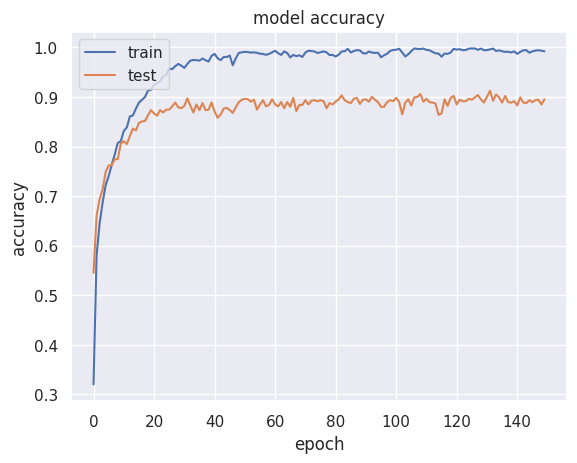

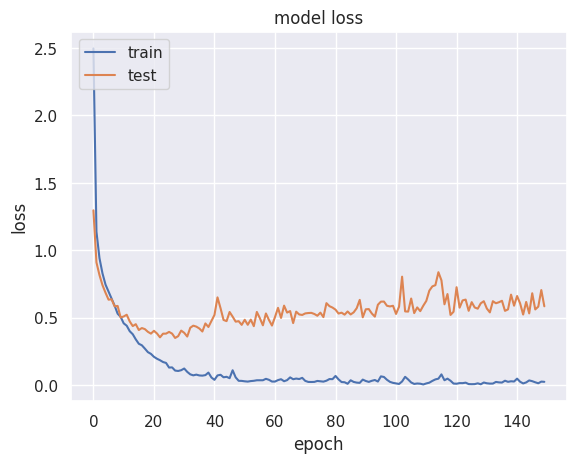

In [ ]:
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Comparando as classes reais com as classes previstas

In [ ]:
predictions = model.predict(X_test, batch_size=32)
predictions = predictions.argmax(axis=1)
predictions

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([4, 0, 7, ..., 7, 1, 1])

In [ ]:
predictions = predictions.astype(int).flatten()
predictions = (labelencoder.inverse_transform((predictions)))
predictions = pd.DataFrame({'Classes Previstas': predictions})

In [ ]:
predictions

,Classes Previstas
0,neutra
1,calma
2,triste
3,triste
4,feliz
...,...
1046,surpreso
1047,feliz
1048,triste
1049,feliz


In [ ]:
actual = y_test.argmax(axis=1)
actual = actual.astype(int).flatten()
actual = (labelencoder.inverse_transform((actual)))
actual = pd.DataFrame({'Classes Reais': actual})

In [ ]:
finaldf = actual.join(predictions)
finaldf[140:150]

,Classes Reais,Classes Previstas
140,neutra,neutra
141,calma,calma
142,calma,calma
143,medo,triste
144,triste,triste
145,triste,triste
146,neutra,neutra
147,nervosa,nervosa
148,triste,triste
149,feliz,feliz


### Exibindo a Matriz de confusão

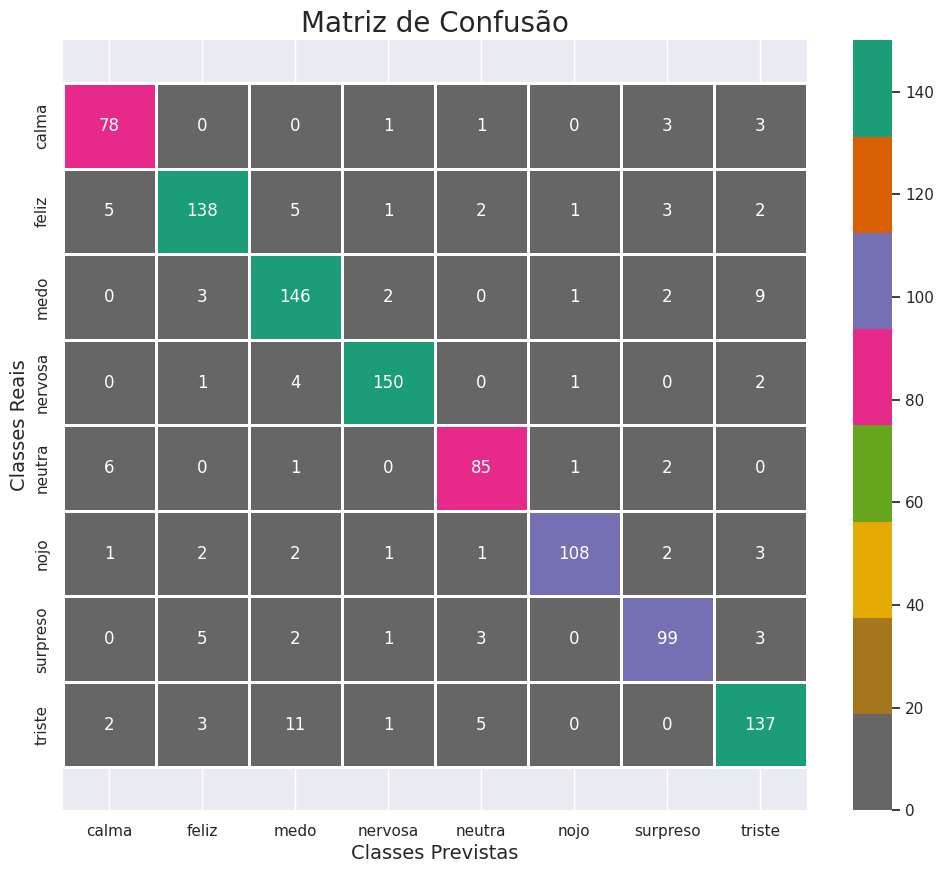

In [ ]:
cm = confusion_matrix(actual, predictions)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in labelencoder.classes_] , columns = [i for i in labelencoder.classes_])
ax = sns.heatmap(cm, linecolor='white', cmap='Dark2_r', linewidth=1, annot=True, fmt='g')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title('Matriz de Confusão', size=20)
plt.xlabel('Classes Previstas', size=14)
plt.ylabel('Classes Reais', size=14)
plt.show()

### Visualizando a taxa e acerto para cada uma das classes

In [ ]:
print(classification_report(actual, predictions))

              precision    recall  f1-score   support

       calma       0.85      0.91      0.88        86
       feliz       0.91      0.88      0.89       157
        medo       0.85      0.90      0.87       163
     nervosa       0.96      0.95      0.95       158
      neutra       0.88      0.89      0.89        95
        nojo       0.96      0.90      0.93       120
    surpreso       0.89      0.88      0.88       113
      triste       0.86      0.86      0.86       159

    accuracy                           0.90      1051
   macro avg       0.89      0.90      0.89      1051
weighted avg       0.90      0.90      0.90      1051



#Função de separação de Audio e Ánalise de Sentimento

In [ ]:
!pip install soundfile
import soundfile as sf

In [ ]:
import numpy as np

In [ ]:
def getInfo(data, sample_rate):
  print('Canais:',  data.shape)
  print('Número total de amostras: ', data.shape[0])
  print('Taxa de amostragem: ', sample_rate)
  print('Duração:',  len(data) / sample_rate)

In [ ]:
def predictSound(AUDIO, info=False, plot_waveform=False, plot_spectrogram=False):
    # Carregar o áudio
    audio, sample_rate = librosa.load(AUDIO, sr=22050, res_type='kaiser_fast')

    # Extrair características MFCC do áudio
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)
    mfccs_scaled_features = mfccs_scaled_features.reshape(1, -1)
    mfccs_scaled_features = mfccs_scaled_features[:, :, np.newaxis]

    # Fazer a predição
    predictions = model.predict(mfccs_scaled_features, batch_size=32)

    # Plotar um gráfico horizontal das classes e probabilidades
    plt.barh(labelencoder.classes_, predictions[0], color=list('rgbkymc'))

    # Extrair a classe com maior probabilidade
    predictions = predictions.argmax(axis=1)
    predictions = predictions.astype(int).flatten()

    # Converter de volta à etiqueta original (sentimento)
    sentimento = labelencoder.inverse_transform(predictions)[0]  # Pega o primeiro valor diretamente

    print(f'Resultado: {sentimento}')  # Mostra o sentimento previsto

    if info:
        getInfo(audio, sample_rate)

    # Verificações opcionais de visualização
    # if plot_waveform:
    #     plt.figure(figsize=(14,5))
    #     plt.title('Emoção: ' + str(sentimento).upper(), size=16)
    #     plt.xlabel("Tempo (segundos) ==>")
    #     plt.ylabel("Amplitude")
    #     ld.waveshow(audio, sr=sample_rate)

    # if plot_spectrogram:
    #     plt.figure(figsize=(14,5))
    #     mfccs_db = librosa.amplitude_to_db(np.abs(mfccs_features))
    #     plt.title('Emoção: ' + str(sentimento).upper(), size=16)
    #     ld.specshow(mfccs_db, x_axis="time", y_axis='log', cmap='Spectral')
    #     plt.colorbar(format='%+2.f dB')

    return sentimento  # Retornar apenas o sentimento como string


In [ ]:
def analise_nps(AUDIO):
    try:
        # Carregar o áudio e separar os canais
        audio, sample_rate = librosa.load(AUDIO, res_type='kaiser_best')
        stereo_data, sample_rate = librosa.load(AUDIO, mono=False, duration=180)
        canal_esquerdo = stereo_data[0, :]  # separação para canal esquerdo

        nome_arquivo_cliente = os.path.splitext(os.path.basename(AUDIO))[0]

        # Caminho para salvar o áudio separado do cliente
        pasta_saida_audios = '/content/Amostra Clientes/'
        os.makedirs(pasta_saida_audios, exist_ok=True)

        # Salvar o áudio processado do cliente (canal esquerdo)
        caminho_cliente_audio = os.path.join(pasta_saida_audios, f'{nome_arquivo_cliente}_Cliente.wav')
        sf.write(caminho_cliente_audio, canal_esquerdo, sample_rate)

        # Analisar o sentimento do áudio processado
        sentimento = predictSound(caminho_cliente_audio)

        # Verificação se o sentimento foi retornado
        if not sentimento:
            sentimento = "indefinido"  # Valor padrão se não houver retorno

        return sentimento

    except Exception as e:
        print(f"Erro ao processar o arquivo {AUDIO}: {e}")
        return "erro"

In [ ]:
# Caminho da pasta com os áudios
pasta_audios = '/content/Amostra de Dados'

# Listar todos os arquivos de áudio na pasta
arquivos = [f for f in os.listdir(pasta_audios) if f.endswith('.wav')]

# Criar uma lista para armazenar os dados
dados_sentimento = []

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Resultado: neutra
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Resultado: neutra
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Resultado: triste
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Resultado: neutra
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Resultado: neutra
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Resultado: feliz
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Resultado: feliz
1/1 ━

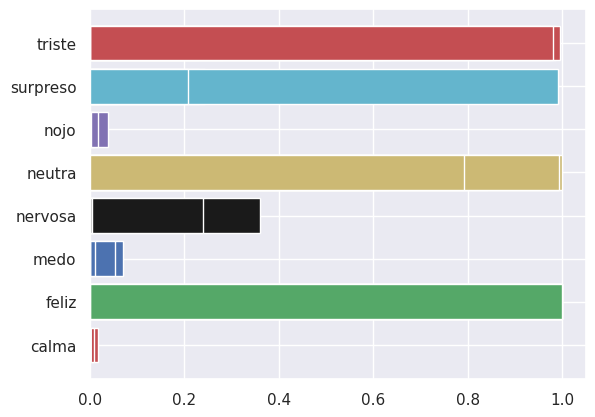

In [ ]:
# Loop para processar cada arquivo de áudio
for arquivo in arquivos:
    caminho_audio = os.path.join(pasta_audios, arquivo)  # Cria o caminho completo do arquivo
    sentimento = analise_nps(caminho_audio)  # Chama a função para analisar o áudio
    dados_sentimento.append({'NOME_ARQUIVO': arquivo, 'SENTIMENTO': sentimento})  # Armazena o nome do arquivo e o sentimento

In [ ]:
df_sentimentos = pd.DataFrame(dados_sentimento)

In [ ]:
indata_nps = pd.read_csv('indata.csv')

In [ ]:
df_completo = pd.merge(indata_nps, df_sentimentos[['NOME_ARQUIVO', 'SENTIMENTO']], on='NOME_ARQUIVO', how='left')

# Passo 3: Verificar se a junção foi bem-sucedida
print(df_completo.head())

# Passo 4: Salvar o novo DataFrame com a coluna de sentimentos adicionada
df_completo.to_csv('/content/indata_nps_com_sentimento.csv', index=False)

  NOME_ARQUIVO  PROBABILIDADE_RECOMENDACAO  AGILIDADE_PROCESSO  \
0  2968540.wav                        10.0                 0.0   
1  2966683.wav                         NaN                 NaN   
2  2966760.wav                        10.0                 8.0   
3  2966719.wav                        10.0                 0.0   
4  2968468.wav                         7.0                 7.0   

   ATENDIMENTO_AGENTES  ATENDIMENTO_COMERCIAL  ATENDIMENTO_FINANCEIRO  \
0                  NaN                    NaN                     0.0   
1                  NaN                    NaN                     NaN   
2                 10.0                   10.0                    10.0   
3                  5.0                    8.0                    10.0   
4                  NaN                    NaN                     NaN   

   CUSTOS_PRODUTOS  IMPLATACAO ATENDE_NECESSIDADE SENTIMENTO  
0              NaN         0.0              total     triste  
1              NaN         NaN        

In [ ]:
pd.read_csv('/content/indata_nps_com_sentimento.csv')

,NOME_ARQUIVO,PROBABILIDADE_RECOMENDACAO,AGILIDADE_PROCESSO,ATENDIMENTO_AGENTES,ATENDIMENTO_COMERCIAL,ATENDIMENTO_FINANCEIRO,CUSTOS_PRODUTOS,IMPLATACAO,ATENDE_NECESSIDADE,SENTIMENTO
0,2968540.wav,10.0,0.0,NaN,NaN,0.0,NaN,0.0,total,triste
1,2966683.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,feliz
2,2966760.wav,10.0,8.0,10.0,10.0,10.0,8.0,9.0,parcial,neutra
3,2966719.wav,10.0,0.0,5.0,8.0,10.0,3.0,10.0,total,triste
4,2968468.wav,7.0,7.0,NaN,NaN,NaN,NaN,NaN,total,neutra
5,2968125.wav,9.0,0.0,10.0,10.0,10.0,0.0,0.0,total,feliz
6,2967703.wav,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,neutra
7,2966138.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,feliz
8,2966819.wav,8.0,8.0,8.0,8.0,8.0,NaN,NaN,parcial,feliz
9,2966642.wav,10.0,10.0,10.0,5.0,NaN,NaN,NaN,total,feliz


In [ ]:
pip install mutagen


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import librosa

# Caminho da pasta onde estão os áudios
pasta_audios = '/content/Amostra de Dados'

# Carregar o dataset existente
df = pd.read_csv('/content/indata_nps_com_sentimento.csv')

# Listar os arquivos de áudio na pasta
arquivos_audio = os.listdir(pasta_audios)

# Função para obter a duração do áudio e a data de modificação
def obter_info_audio(arquivo):
    # Caminho completo do arquivo
    caminho_audio = os.path.join(pasta_audios, arquivo)

    # Obter a duração do áudio em segundos
    try:
        duracao = librosa.get_duration(filename=caminho_audio)
    except Exception as e:
        duracao = None
        print(f"Erro ao processar o áudio {arquivo}: {e}")

    # Obter a data de modificação
    data_modificacao = os.path.getmtime(caminho_audio)

    return duracao, data_modificacao

# Criar listas para armazenar as informações
duracoes = []
datas_modificacao = []

# Iterar sobre os arquivos de áudio e obter as informações
for arquivo in df['NOME_ARQUIVO']:  # Garantir que estamos apenas pegando os arquivos que estão no dataset
    if arquivo in arquivos_audio:  # Verificar se o arquivo existe na pasta
        duracao, data_modificacao = obter_info_audio(arquivo)
        duracoes.append(duracao)
        datas_modificacao.append(pd.to_datetime(data_modificacao, unit='s'))  # Converter para datetime
    else:
        duracoes.append(None)  # Caso o arquivo não exista
        datas_modificacao.append(None)

# Converter a duração para o formato "MM:SS"
duracoes_formatadas = []
for duracao in duracoes:
    if duracao is not None:
        minutos = int(duracao // 60)
        segundos = int(duracao % 60)
        duracoes_formatadas.append(f"{minutos}:{segundos:02d}")
    else:
        duracoes_formatadas.append(None)

# Adicionar as novas colunas ao DataFrame
df['DURACAO_AUDIO'] = duracoes_formatadas
df['DATA_MODIFICACAO'] = datas_modificacao

# Salvar o DataFrame atualizado em um novo arquivo CSV
df.to_csv('/content/indata_nps_com_sentimento.csv', index=False)

print("Colunas de duração e data de modificação adicionadas com sucesso!")


<ipython-input-113-7732a0fefd5b>:21: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  duracao = librosa.get_duration(filename=caminho_audio)


Colunas de duração e data de modificação adicionadas com sucesso!


In [ ]:
pd.read_csv('/content/indata_nps_com_sentimento.csv')

,NOME_ARQUIVO,PROBABILIDADE_RECOMENDACAO,AGILIDADE_PROCESSO,ATENDIMENTO_AGENTES,ATENDIMENTO_COMERCIAL,ATENDIMENTO_FINANCEIRO,CUSTOS_PRODUTOS,IMPLATACAO,ATENDE_NECESSIDADE,SENTIMENTO,DURACAO_AUDIO,DATA_MODIFICACAO
0,2968540.wav,10.0,0.0,NaN,NaN,0.0,NaN,0.0,total,triste,4:01,2024-09-24 02:35:12.649446400
1,2966683.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,feliz,1:36,2024-09-24 02:35:11.746381568
2,2966760.wav,10.0,8.0,10.0,10.0,10.0,8.0,9.0,parcial,neutra,5:23,2024-09-24 02:35:11.865390080
3,2966719.wav,10.0,0.0,5.0,8.0,10.0,3.0,10.0,total,triste,3:33,2024-09-24 02:35:11.796385024
4,2968468.wav,7.0,7.0,NaN,NaN,NaN,NaN,NaN,total,neutra,5:11,2024-09-24 02:35:12.610443520
5,2968125.wav,9.0,0.0,10.0,10.0,10.0,0.0,0.0,total,feliz,4:50,2024-09-24 02:35:12.491435008
6,2967703.wav,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,neutra,4:44,2024-09-24 02:35:12.263418368
7,2966138.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,feliz,1:37,2024-09-24 02:35:11.560368384
8,2966819.wav,8.0,8.0,8.0,8.0,8.0,NaN,NaN,parcial,feliz,6:21,2024-09-24 02:35:11.951396352
9,2966642.wav,10.0,10.0,10.0,5.0,NaN,NaN,NaN,total,feliz,3:29,2024-09-24 02:35:11.703378432
